In [14]:
# Install dependencies required for this notebook (uncomment to run if needed)
# Use %pip to ensure installs go to the notebook kernel
%pip install seaborn statsmodels


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 558.9 kB/s eta 0:00:17
   -- ------------------------------------- 0.5/9.6 MB 558.9 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/9.6 MB 541.1 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/9.6 MB 541.1 kB/s eta 0:00:17
   ---- ----------------------------------- 1.0/9.6 MB 578.7 kB/s eta 0:00:15
   ---- ----------------------------------- 1.0/9.6 MB 578.7 kB/s eta 0:00:15
   ----- ---------------------------------- 1.3/9.6 MB 593.8 kB/s eta 0:00:14
   ----- -------------------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 01 — Spotify Data Exploration

This notebook loads the three provided Spotify CSVs, performs initial cleaning, and runs starter EDA plots. Objectives:
- Inspect schemas and missing values
- Parse datetime / time columns
- Produce distributions, top-k tracks, and time-series plots
- Save cleaned intermediate CSVs to `../data/` for downstream notebooks


In [1]:
# Environment setup

# Install requirements if needed (uncomment to run)
# !pip install -r ../requirements.txt

import sys
import platform
print('Python', sys.version.split()[0])
print('Platform:', platform.platform())


Python 3.10.0
Platform: Windows-10-10.0.26200-SP0


In [4]:
# Imports and dependency checks
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', rc={'figure.figsize':(10,5)})
pd.set_option('display.max_columns', 80)


In [5]:
# Paths and helper functions
DATA_DIR = Path('..') / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

def parse_time_to_seconds(s):
    if pd.isna(s):
        return None
    if isinstance(s, (int, float)):
        return int(s)
    parts = str(s).split(':')
    parts = [int(p) for p in parts]
    if len(parts) == 3:
        h, m, sec = parts
        return h*3600 + m*60 + sec
    if len(parts) == 2:
        m, sec = parts
        return m*60 + sec
    try:
        return int(parts[0])
    except:
        return None


In [8]:
# Load datasets (look first in ../src/ where CSVs were placed)
album_fp = Path('..') / 'src' / 'spotify_skz_counts_album.csv'
day_fp = Path('..') / 'src' / 'spotify_skz_counts_day.csv'
stream_fp = Path('..') / 'src' / 'spotify_skz_streaming_4.25_4.26.csv'

# fallback: original folder
if not album_fp.exists():
    album_fp = Path('..') / 'Machine Learning' / 'Spotify' / 'spotify_skz_counts_album.csv'
if not day_fp.exists():
    day_fp = Path('..') / 'Machine Learning' / 'Spotify' / 'spotify_skz_counts_day.csv'
if not stream_fp.exists():
    stream_fp = Path('..') / 'Machine Learning' / 'Spotify' / 'spotify_skz_streaming_4.25_4.26.csv'

print('Album file:', album_fp)
print('Day file:', day_fp)
print('Stream file:', stream_fp)

# read
df_album = pd.read_csv(album_fp)
df_day = pd.read_csv(day_fp)
# stream file may have non-utf8 encoding — try fallback
try:
    df_stream = pd.read_csv(stream_fp)
except UnicodeDecodeError:
    df_stream = pd.read_csv(stream_fp, encoding='latin-1')

print('\nShapes:')
print('album', df_album.shape)
print('day', df_day.shape)
print('stream', df_stream.shape)

# show sample rows
print('\nAlbum sample:')
df_album.head(3)


Album file: ..\src\spotify_skz_counts_album.csv
Day file: ..\src\spotify_skz_counts_day.csv
Stream file: ..\src\spotify_skz_streaming_4.25_4.26.csv

Shapes:
album (309, 12)
day (1808, 11)
stream (27005, 16)

Album sample:


,release_year,album_type,album_name,track_name,bpm,number_of_streams,total_time_played,total_time_played_h,average_ms_played,average_ms_played_min,song_length_min,avg_percent_song_played
0,2018,Mini Album,I am NOT,3rd Eye,140,32,7554514,2:05:55,236078.56,3:56,4:03,97
1,2018,Mini Album,I am NOT,Awaken,164,33,6399256,1:46:39,193916.85,3:13,3:13,100
2,2018,Mini Album,I am NOT,District 9,90,151,32233152,8:57:13,213464.58,3:33,3:33,100


In [9]:
# Quick inspection: dtypes and missing values
for name, df in [('album', df_album), ('day', df_day), ('stream', df_stream)]:
    print(f"\n{name} — shape={df.shape}")
    display(df.dtypes.value_counts())
    display(df.isna().sum().sort_values(ascending=False).head(10))



album — shape=(309, 12)


object     6
int64      5
float64    1
Name: count, dtype: int64

release_year             0
album_type               0
album_name               0
track_name               0
bpm                      0
number_of_streams        0
total_time_played        0
total_time_played_h      0
average_ms_played        0
average_ms_played_min    0
dtype: int64


day — shape=(1808, 11)


int64      7
object     3
float64    1
Name: count, dtype: int64

end_year                0
end_month               0
end_date                0
end_day                 0
end_hour_UTC            0
end_hour_PST            0
number_of_streams       0
total_time_played_ms    0
total_time_played_h     0
average_ms_played       0
dtype: int64


stream — shape=(27005, 16)


object    9
int64     7
Name: count, dtype: int64

end_time        0
end_year        0
end_month       0
end_date        0
end_day         0
end_hour_UTC    0
end_hour_PST    0
artist_name     0
track_name      0
album_name      0
dtype: int64

In [10]:
# Data cleaning & feature engineering — album
# parse song length if present
if 'song_length_min' in df_album.columns:
    df_album['song_length_sec'] = df_album['song_length_min'].apply(parse_time_to_seconds)

# ensure numeric
for col in ['bpm','number_of_streams','average_ms_played','avg_percent_song_played']:
    if col in df_album.columns:
        df_album[col] = pd.to_numeric(df_album[col], errors='coerce')

# derived
if 'average_ms_played' in df_album.columns:
    df_album['avg_played_sec'] = df_album['average_ms_played'] / 1000.0

# preview
df_album.select_dtypes(include=[np.number]).describe().T


,count,mean,std,min,25%,50%,75%,max
release_year,309.0,2.022032e+03,2.257510e+00,2018.000,2.020000e+03,2022.000,2.024000e+03,2.026000e+03
bpm,309.0,1.258155e+02,3.170196e+01,65.000,9.800000e+01,125.000,1.540000e+02,2.000000e+02
number_of_streams,309.0,8.739482e+01,1.100935e+02,5.000,2.500000e+01,37.000,7.900000e+01,4.630000e+02
total_time_played,309.0,1.570893e+07,1.958584e+07,416436.000,4.941913e+06,6753131.000,1.563875e+07,9.574916e+07
average_ms_played,309.0,1.847103e+05,3.065515e+04,78834.000,1.668107e+05,185435.000,2.022097e+05,2.918450e+05
avg_percent_song_played,309.0,9.715210e+01,5.371839e+00,34.000,9.700000e+01,98.000,1.000000e+02,1.000000e+02
song_length_sec,309.0,1.897605e+02,2.994748e+01,78.000,1.730000e+02,190.000,2.080000e+02,2.910000e+02
avg_played_sec,309.0,1.847103e+02,3.065515e+01,78.834,1.668107e+02,185.435,2.022097e+02,2.918450e+02


In [11]:
# Data cleaning — day
# construct datetime
try:
    df_day['datetime'] = pd.to_datetime(df_day[['end_year','end_month','end_date','end_hour_UTC']].astype(str).agg('-'.join, axis=1), format='%Y-%m-%d-%H')
except Exception:
    # fallback: combine strings
    df_day['datetime'] = pd.to_datetime(df_day.apply(lambda r: f"{int(r.end_year)}-{int(r.end_month):02d}-{int(r.end_date):02d} {int(r.end_hour_UTC):02d}:00:00", axis=1))

for col in ['number_of_streams','average_ms_played','total_time_played_ms']:
    if col in df_day.columns:
        df_day[col] = pd.to_numeric(df_day[col], errors='coerce')

# hourly aggregation check
hourly = df_day.groupby(df_day['datetime'].dt.floor('H'))['number_of_streams'].sum().rename('streams')
hourly.head()


C:\Users\muhmd\AppData\Local\Temp\ipykernel_15412\812231346.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df_day.groupby(df_day['datetime'].dt.floor('H'))['number_of_streams'].sum().rename('streams')


datetime
2025-04-17 19:00:00     1
2025-04-18 15:00:00    14
2025-04-18 16:00:00    19
2025-04-18 17:00:00    19
2025-04-18 18:00:00    19
Name: streams, dtype: int64

In [12]:
# Data cleaning — streaming logs
if 'end_time' in df_stream.columns:
    df_stream['end_time_dt'] = pd.to_datetime(df_stream['end_time'], errors='coerce')
for col in ['played_ms']:
    if col in df_stream.columns:
        df_stream[col] = pd.to_numeric(df_stream[col], errors='coerce')
        df_stream['played_sec'] = df_stream['played_ms'] / 1000.0

# quick check
df_stream[['end_time_dt','artist_name','track_name','played_sec']].head()


,end_time_dt,artist_name,track_name,played_sec
0,2025-04-17 19:42:00,Stray Kids,Truman (HAN and Felix),140.543
1,2025-04-18 15:18:00,Stray Kids,Truman (HAN and Felix),23.984
2,2025-04-18 15:21:00,Stray Kids,Burnin' Tires (Changbin and I.N),172.413
3,2025-04-18 15:24:00,Stray Kids,Truman (HAN and Felix),194.400
4,2025-04-18 15:28:00,Stray Kids,ESCAPE (Bang Chan and Hyunjin),190.166


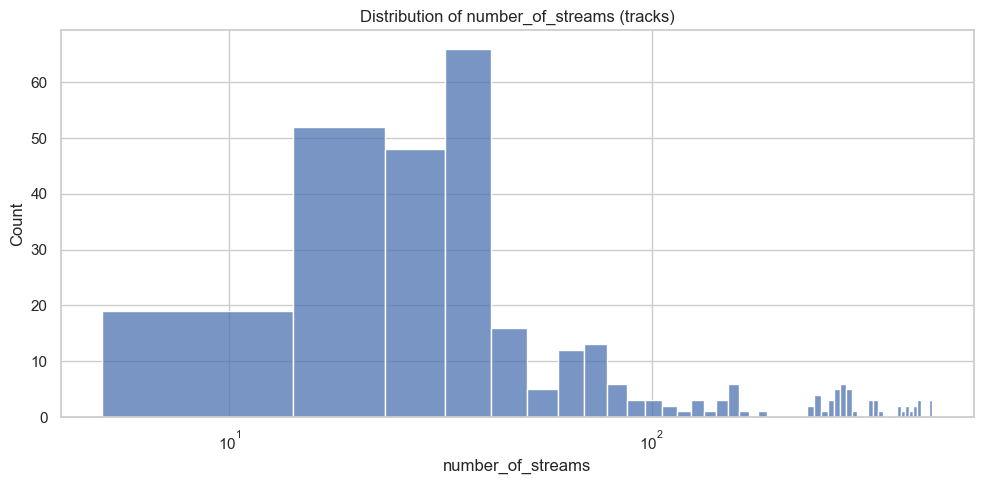

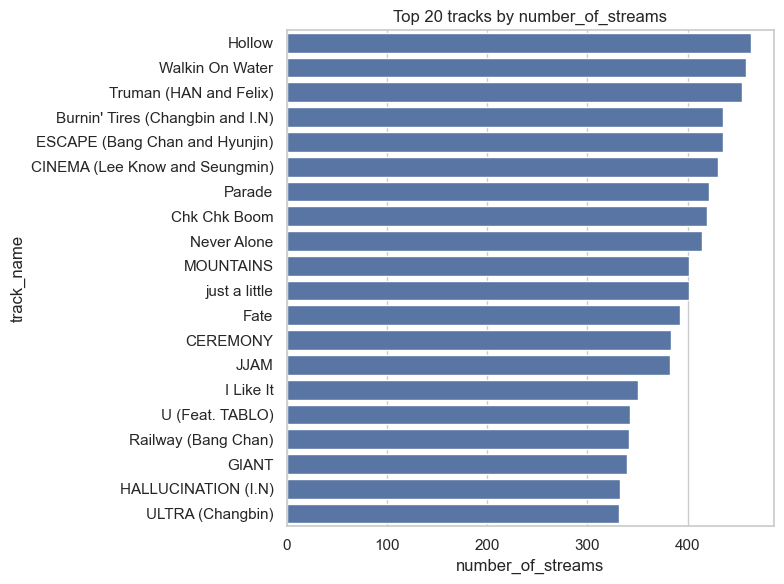

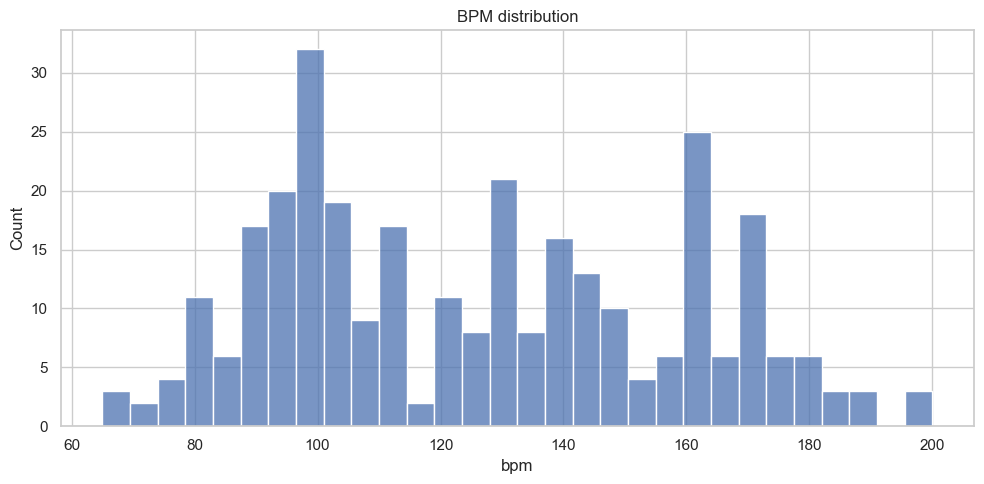

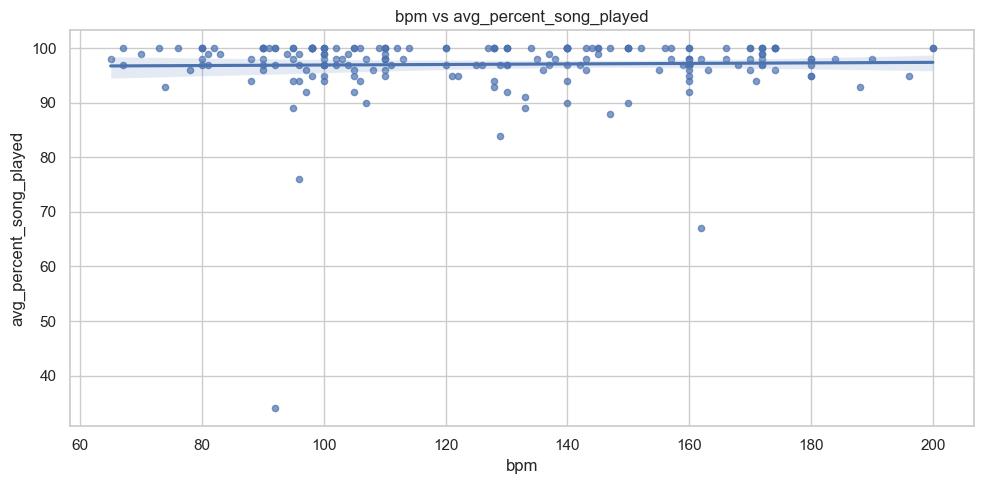

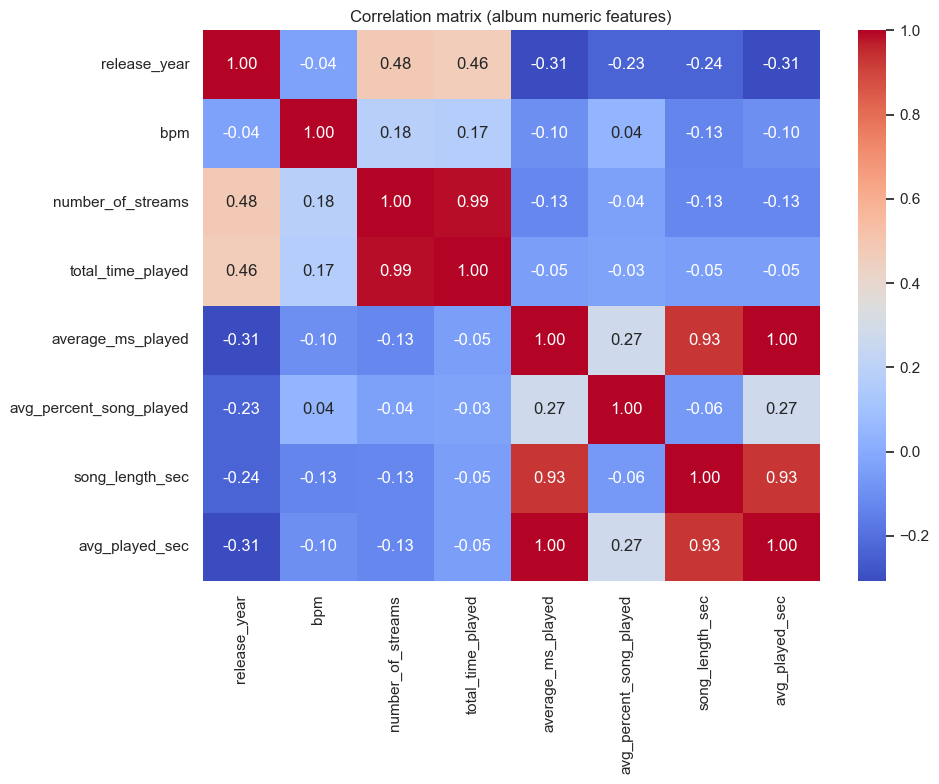

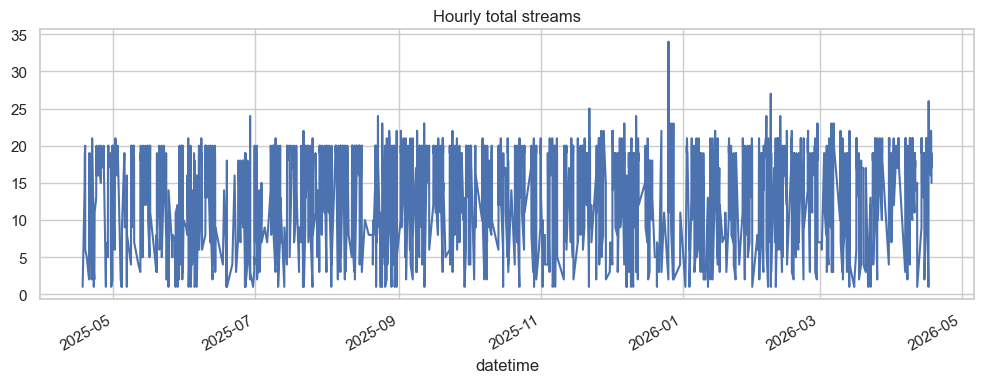

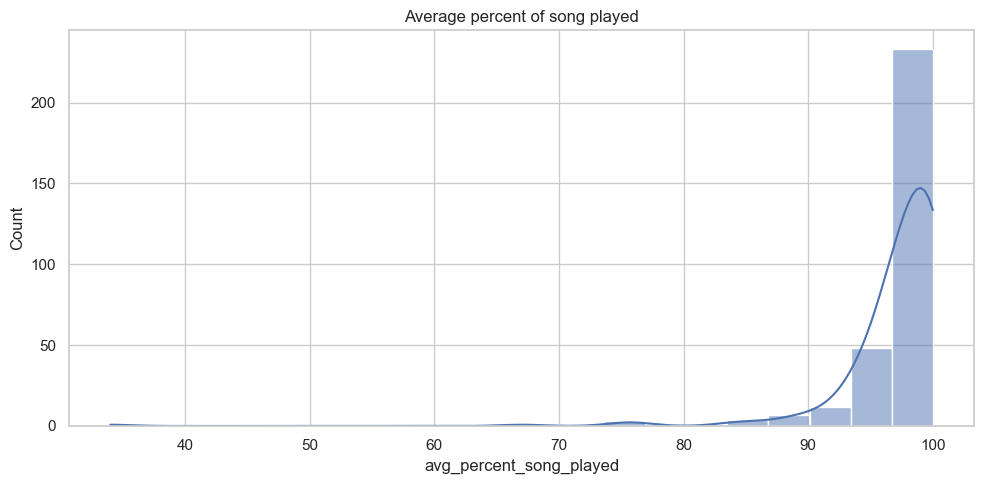

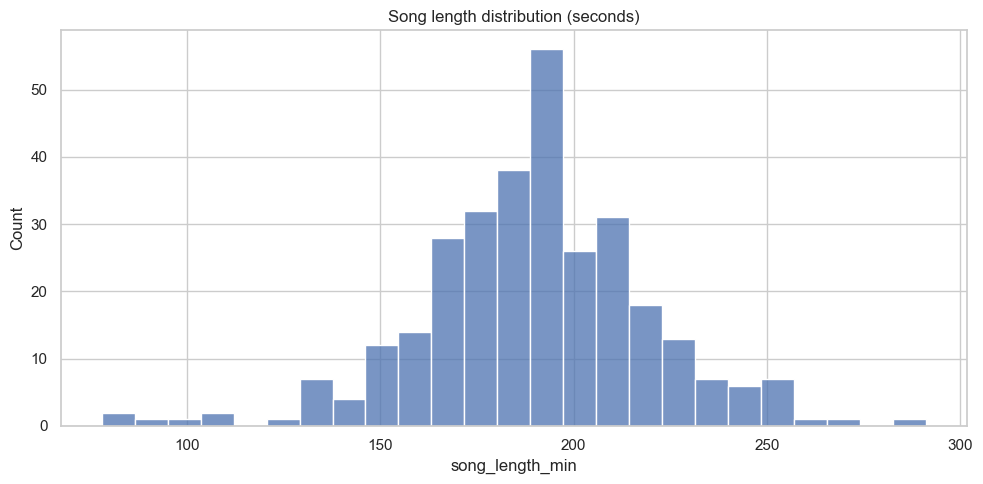

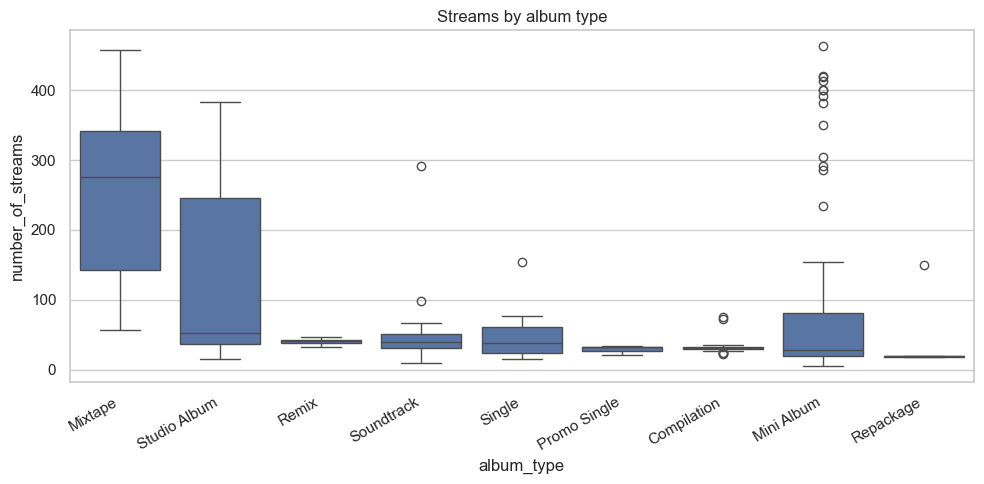

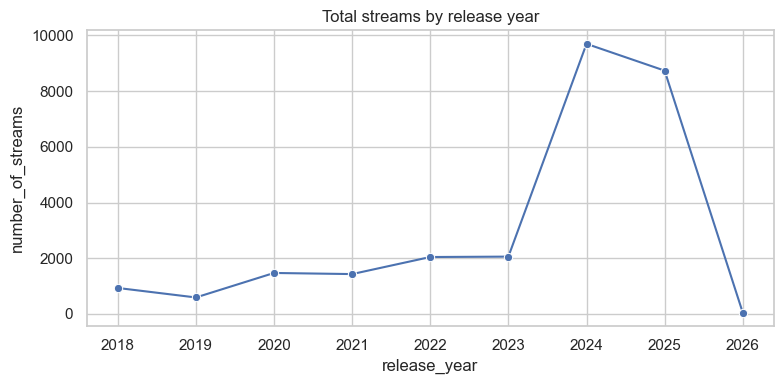

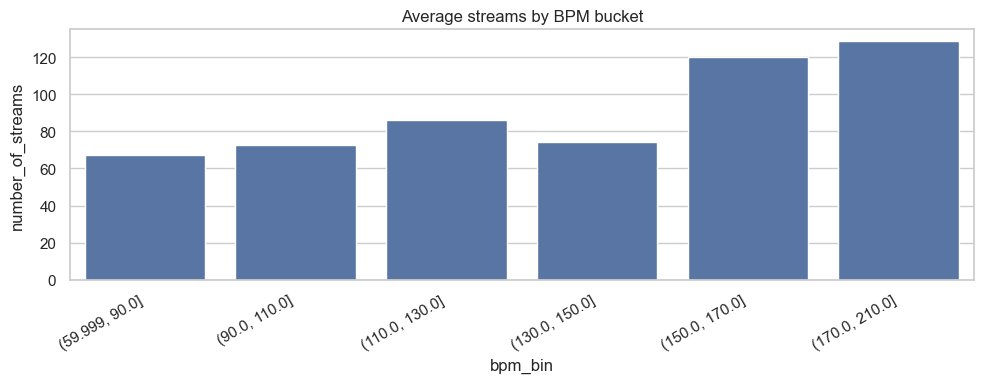

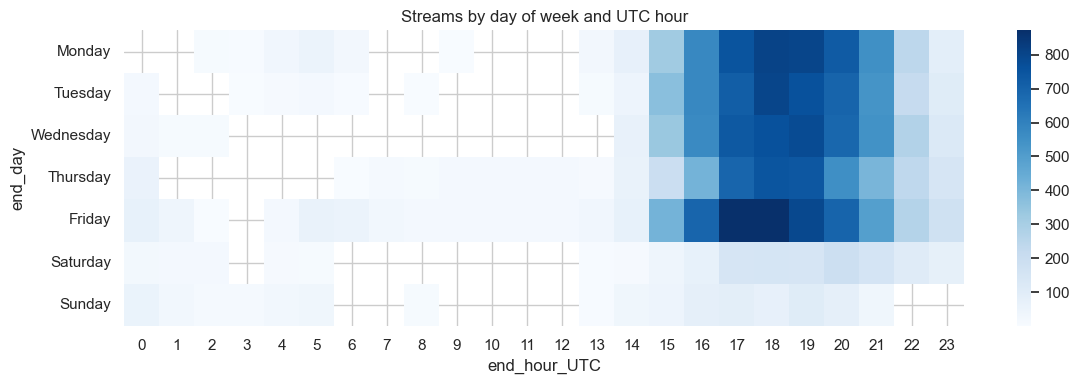

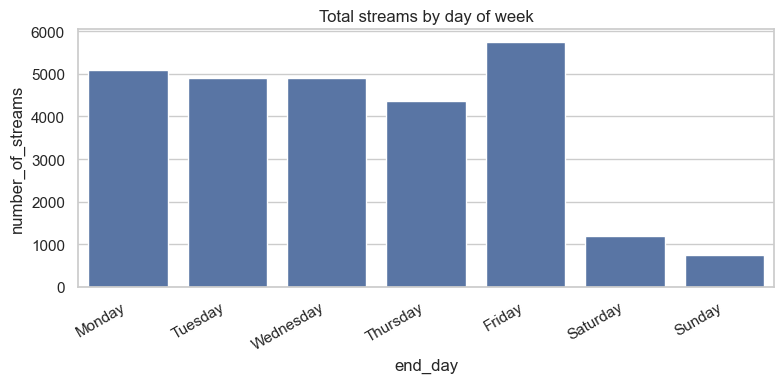

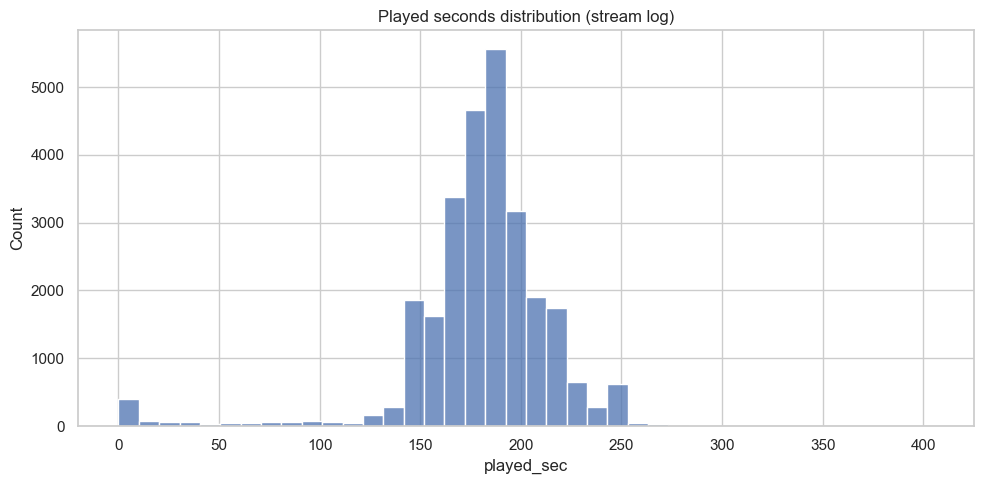

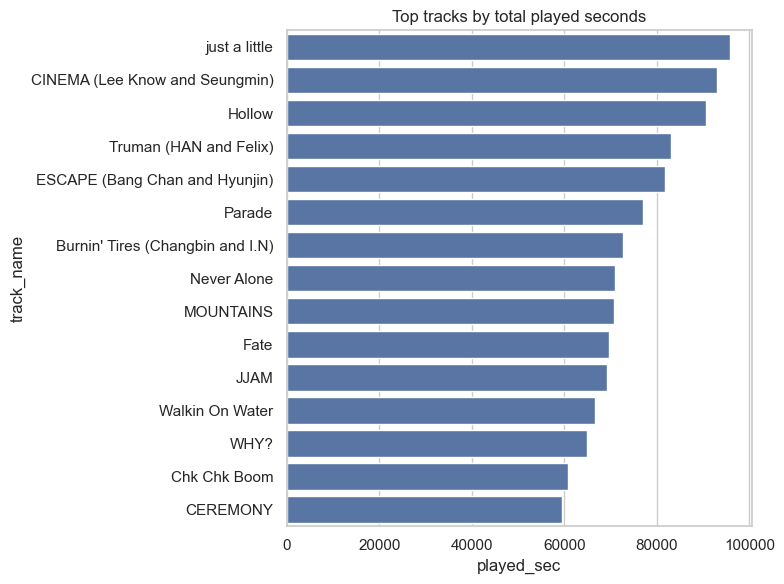

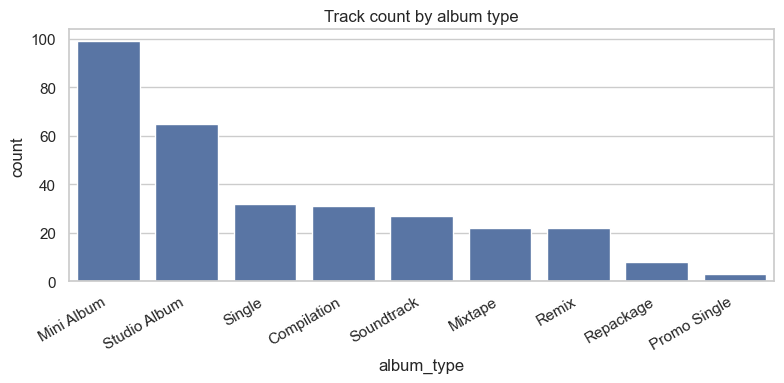

EDA block completed successfully.


In [16]:
# Starter EDA plots

# 1. Distribution: number_of_streams (album)
if 'number_of_streams' in df_album.columns:
    plt.figure()
    sns.histplot(df_album['number_of_streams'].dropna(), bins=50, kde=False)
    plt.title('Distribution of number_of_streams (tracks)')
    plt.xscale('log')
    plt.tight_layout()
    plt.show()

# 2. Top-20 tracks by streams
if 'number_of_streams' in df_album.columns and 'track_name' in df_album.columns:
    top20 = df_album.nlargest(20, 'number_of_streams')[['track_name', 'number_of_streams']]
    plt.figure(figsize=(8, 6))
    sns.barplot(y='track_name', x='number_of_streams', data=top20)
    plt.title('Top 20 tracks by number_of_streams')
    plt.tight_layout()
    plt.show()

# 3. BPM distribution
if 'bpm' in df_album.columns:
    plt.figure()
    sns.histplot(df_album['bpm'].dropna(), bins=30)
    plt.title('BPM distribution')
    plt.tight_layout()
    plt.show()

# 4. Scatter: bpm vs avg_percent_song_played
if set(['bpm', 'avg_percent_song_played']).issubset(df_album.columns):
    plt.figure()
    sample_df = df_album.sample(min(200, len(df_album)), random_state=42)
    sns.regplot(x='bpm', y='avg_percent_song_played', data=sample_df, scatter_kws={'s': 20, 'alpha': 0.7}, lowess=False)
    plt.title('bpm vs avg_percent_song_played')
    plt.tight_layout()
    plt.show()

# 5. Correlation heatmap numeric
numcols = df_album.select_dtypes(include=[np.number])
if numcols.shape[1] > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numcols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation matrix (album numeric features)')
    plt.tight_layout()
    plt.show()

# 6. Time-series: hourly streams (from df_day)
if 'datetime' in df_day.columns and 'number_of_streams' in df_day.columns:
    ts = df_day.groupby(df_day['datetime'].dt.floor('h'))['number_of_streams'].sum()
    plt.figure(figsize=(10, 4))
    ts.plot()
    plt.title('Hourly total streams')
    plt.tight_layout()
    plt.show()

# 7. Avg percent song played distribution
if 'avg_percent_song_played' in df_album.columns:
    plt.figure()
    sns.histplot(df_album['avg_percent_song_played'].dropna(), bins=20, kde=True)
    plt.title('Average percent of song played')
    plt.tight_layout()
    plt.show()

# 8. Song length distribution
if 'song_length_min' in df_album.columns:
    plt.figure()
    song_len_sec = df_album['song_length_min'].apply(parse_time_to_seconds)
    sns.histplot(song_len_sec.dropna(), bins=25)
    plt.title('Song length distribution (seconds)')
    plt.tight_layout()
    plt.show()

# 9. Streams by album type
if set(['album_type', 'number_of_streams']).issubset(df_album.columns):
    plt.figure(figsize=(10, 5))
    order = df_album.groupby('album_type')['number_of_streams'].median().sort_values(ascending=False).index
    sns.boxplot(data=df_album, x='album_type', y='number_of_streams', order=order)
    plt.xticks(rotation=30, ha='right')
    plt.title('Streams by album type')
    plt.tight_layout()
    plt.show()

# 10. Streams by release year
if set(['release_year', 'number_of_streams']).issubset(df_album.columns):
    yearly = df_album.groupby('release_year', as_index=False)['number_of_streams'].sum()
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=yearly, x='release_year', y='number_of_streams', marker='o')
    plt.title('Total streams by release year')
    plt.tight_layout()
    plt.show()

# 11. Streams by BPM buckets
if set(['bpm', 'number_of_streams']).issubset(df_album.columns):
    bpm_bins = pd.cut(df_album['bpm'], bins=[60, 90, 110, 130, 150, 170, 210], include_lowest=True)
    bpm_group = df_album.assign(bpm_bin=bpm_bins).groupby('bpm_bin', observed=False)['number_of_streams'].mean().reset_index()
    plt.figure(figsize=(10, 4))
    sns.barplot(data=bpm_group, x='bpm_bin', y='number_of_streams')
    plt.xticks(rotation=30, ha='right')
    plt.title('Average streams by BPM bucket')
    plt.tight_layout()
    plt.show()

# 12. Day-of-week stream heatmap
if set(['end_day', 'end_hour_UTC', 'number_of_streams']).issubset(df_day.columns):
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot = df_day.pivot_table(index='end_day', columns='end_hour_UTC', values='number_of_streams', aggfunc='sum').reindex(dow_order)
    plt.figure(figsize=(12, 4))
    sns.heatmap(pivot, cmap='Blues')
    plt.title('Streams by day of week and UTC hour')
    plt.tight_layout()
    plt.show()

# 13. Day-of-week stream totals
if set(['end_day', 'number_of_streams']).issubset(df_day.columns):
    dow_totals = df_day.groupby('end_day', as_index=False)['number_of_streams'].sum()
    plt.figure(figsize=(8, 4))
    sns.barplot(data=dow_totals, x='end_day', y='number_of_streams', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
    plt.xticks(rotation=30, ha='right')
    plt.title('Total streams by day of week')
    plt.tight_layout()
    plt.show()

# 14. Played seconds distribution (stream log)
if 'played_sec' in df_stream.columns:
    plt.figure()
    sns.histplot(df_stream['played_sec'].dropna(), bins=40)
    plt.title('Played seconds distribution (stream log)')
    plt.tight_layout()
    plt.show()

# 15. Top tracks in streaming logs
if set(['track_name', 'played_sec']).issubset(df_stream.columns):
    top_stream_tracks = df_stream.groupby('track_name', as_index=False)['played_sec'].sum().sort_values('played_sec', ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(data=top_stream_tracks, y='track_name', x='played_sec')
    plt.title('Top tracks by total played seconds')
    plt.tight_layout()
    plt.show()

# 16. Album type counts
if 'album_type' in df_album.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_album, x='album_type', order=df_album['album_type'].value_counts().index)
    plt.xticks(rotation=30, ha='right')
    plt.title('Track count by album type')
    plt.tight_layout()
    plt.show()

print('EDA block completed successfully.')


In [ ]:
# Save cleaned intermediate CSVs
clean_dir = DATA_DIR

df_album.to_csv(clean_dir / 'cleaned_album.csv', index=False)
df_day.to_csv(clean_dir / 'cleaned_day.csv', index=False)
df_stream.to_csv(clean_dir / 'cleaned_stream.csv', index=False)

print('Saved cleaned files to', clean_dir)


# Next steps

- Feature engineering notebook: `02-feature-engineering.ipynb` (derive artist aggregates, rolling features, label definitions for regression/classification)
- Modeling notebook: `03-modeling.ipynb` (baseline models, comparison, and saving best model)

